In [5]:
#importing libraries we will need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Model Implementation From Scratch

In [6]:
#reading the csv file and converting it to a pandas dataframe

power = pd.read_csv('Tetuan City power consumption.csv')
power.head()

,DateTime,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/17 0:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,1/1/17 0:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,1/1/17 0:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,1/1/17 0:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,1/1/17 0:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


In [3]:
#gathering information and summary statistics of our dataset

power.info()
power.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DateTime                  52416 non-null  object 
 1   Temperature               52416 non-null  float64
 2   Humidity                  52416 non-null  float64
 3   Wind Speed                52416 non-null  float64
 4   Zone 1 Power Consumption  52416 non-null  float64
 5   Zone 2 Power Consumption  52416 non-null  float64
 6   Zone 3 Power Consumption  52416 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360


### Data Visualization

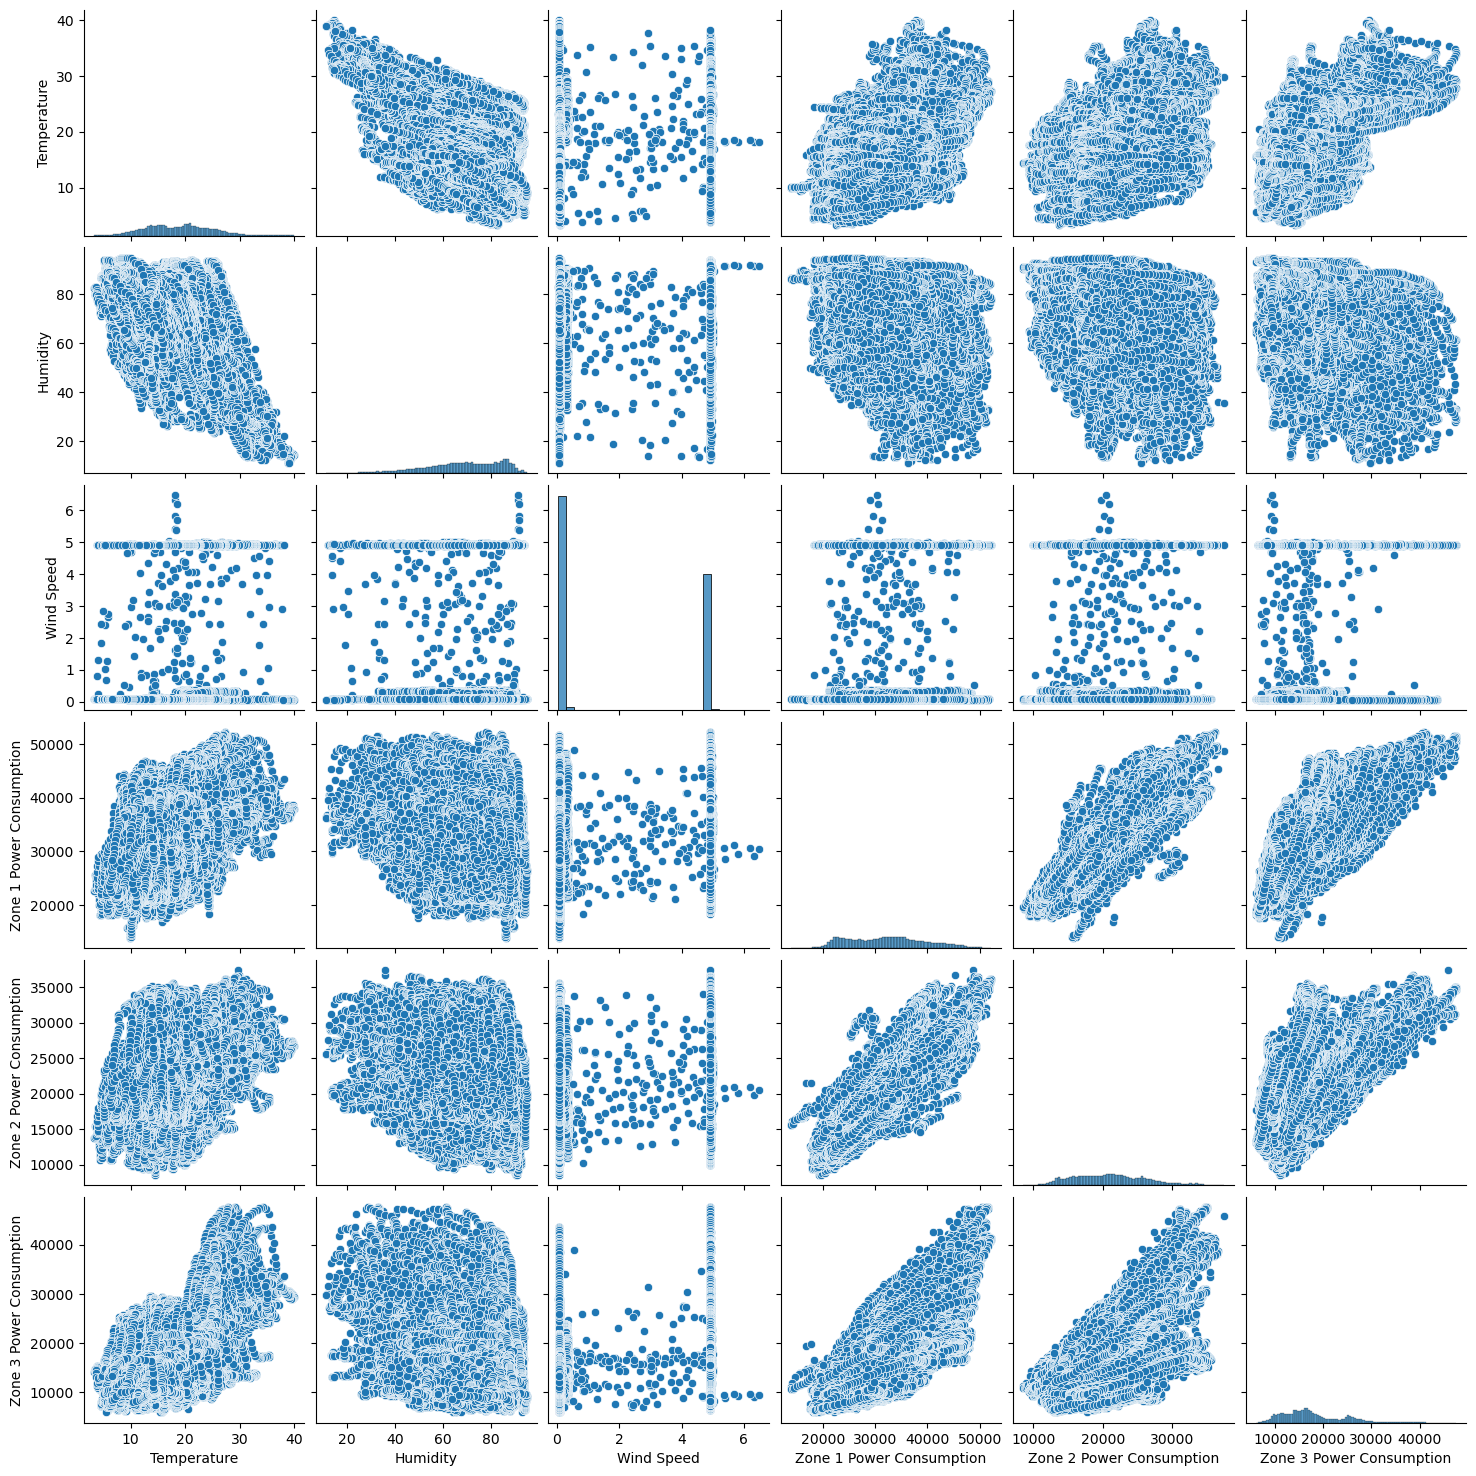

In [4]:
#scatterplots comparing all of the datapoints using seaborn

sns.pairplot(power)

Text(0.5, 1.0, 'Feature Correlation Heatmap')

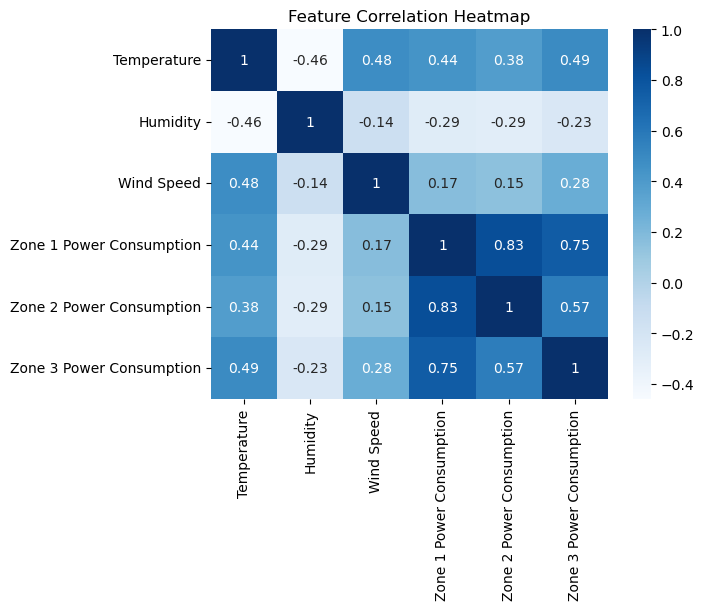

In [5]:
#calculating correlation coefficients and using a heatmap to see and compare them

corr = power[['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption', 'Zone 2 Power Consumption', 'Zone 3 Power Consumption']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Feature Correlation Heatmap')

In [14]:
#copying power dataframe and picking columns of interest, creating 3 dataframes for each zone

df = power.copy()
df = df.iloc[:, 1:4] #will be important in the next cell
df1 = power.iloc[:, 1:5]
df2 = power.iloc[:, [1, 2, 3, 5]]
df3 = power.iloc[:, [1, 2, 3, 6]]

print(df1.head())
print()
print(df2.head())
print()
print(df3.head())
print()

print(df1.describe())
print()
print(df2.describe())
print()
print(df3.describe())

   Temperature  Humidity  Wind Speed  Zone 1 Power Consumption
0        6.559      73.8       0.083               34055.69620
1        6.414      74.5       0.083               29814.68354
2        6.313      74.5       0.080               29128.10127
3        6.121      75.0       0.083               28228.86076
4        5.921      75.7       0.081               27335.69620

   Temperature  Humidity  Wind Speed  Zone 2 Power Consumption
0        6.559      73.8       0.083               16128.87538
1        6.414      74.5       0.083               19375.07599
2        6.313      74.5       0.080               19006.68693
3        6.121      75.0       0.083               18361.09422
4        5.921      75.7       0.081               17872.34043

   Temperature  Humidity  Wind Speed  Zone 3 Power Consumption
0        6.559      73.8       0.083               20240.96386
1        6.414      74.5       0.083               20131.08434
2        6.313      74.5       0.080               19

In [26]:
#converting feature columns to standard units and adding it to each dataframe

df['Temperature (standard units)'] = (df['Temperature'] - np.mean(df['Temperature'])) / (np.std(df['Temperature']))
df['Humidity (standard units)'] = (df['Humidity'] - np.mean(df['Humidity'])) / (np.std(df['Humidity']))
df['Wind Speed (standard units)'] = (df['Wind Speed'] - np.mean(df['Wind Speed'])) / (np.std(df['Wind Speed']))

df1['Temperature (standard units)'] = df.iloc[:, 3] 
df1['Humidity (standard units)'] = df.iloc[:, 4]
df1['Wind Speed (standard units)'] = df.iloc[:, 5]

df2['Temperature (standard units)'] = df.iloc[:, 3] 
df2['Humidity (standard units)'] = df.iloc[:, 4]
df2['Wind Speed (standard units)'] = df.iloc[:, 5]

df3['Temperature (standard units)'] = df.iloc[:, 3] 
df3['Humidity (standard units)'] = df.iloc[:, 4]
df3['Wind Speed (standard units)'] = df.iloc[:, 5]

print(df1.head())
print()
print(df2.head())
print()
print(df3.head())

   Temperature  Humidity  Wind Speed  Zone 1 Power Consumption  \
0        6.559      73.8       0.083               34055.69620   
1        6.414      74.5       0.083               29814.68354   
2        6.313      74.5       0.080               29128.10127   
3        6.121      75.0       0.083               28228.86076   
4        5.921      75.7       0.081               27335.69620   

   Temperature (standard units)  Humidity (standard units)  \
0                     -2.106645                   0.356277   
1                     -2.131578                   0.401291   
2                     -2.148946                   0.401291   
3                     -2.181962                   0.433443   
4                     -2.216353                   0.478456   

   Wind Speed (standard units)  
0                    -0.798900  
1                    -0.798900  
2                    -0.800178  
3                    -0.798900  
4                    -0.799752  

   Temperature  Humidity  Wind 

In [30]:
#randomly shuffling each dataset (without replacement) and assigning first 2/3 of the rows as the training set and the rest as the test set

random1 = df1.sample(52416, replace = False)
training_set1 = random1.iloc[0:34944, :]
test_set1 = random1.iloc[34944:, :]

random2 = df2.sample(52416, replace = False)
training_set2 = random2.iloc[0:34944, :]
test_set2 = random2.iloc[34944:, :]

random3 = df3.sample(52416, replace = False)
training_set3 = random3.iloc[0:34944, :]
test_set3 = random3.iloc[34944:, :]

print('df1:')
print(len(training_set1))
print(len(test_set1))
print()

print('df2:')
print(len(training_set2))
print(len(test_set2))
print()

print('df3:')
print(len(training_set3))
print(len(test_set3))

df1:
34944
17472

df2:
34944
17472

df3:
34944
17472


In [33]:
#separating input variables and the output variable into x and y for the training and test sets

x_train1 = training_set1.iloc[:, 4:].values
y_train1 = training_set1.iloc[:, 3].values
y_train1 = np.reshape(y_train1, (len(y_train1), 1))

x_test1 = test_set1.iloc[:, 4:].values
y_test1 = test_set1.iloc[:, 3].values
y_test1 = np.reshape(y_test1, (len(y_test1), 1))

x_train2 = training_set2.iloc[:, 4:].values
y_train2 = training_set2.iloc[:, 3].values
y_train2 = np.reshape(y_train2, (len(y_train2), 1))

x_test2 = test_set2.iloc[:, 4:].values
y_test2 = test_set2.iloc[:, 3].values
y_test2 = np.reshape(y_test2, (len(y_test2), 1))

x_train3 = training_set3.iloc[:, 4:].values
y_train3 = training_set3.iloc[:, 3].values
y_train3 = np.reshape(y_train3, (len(y_train3), 1))

x_test3 = test_set3.iloc[:, 4:].values
y_test3 = test_set3.iloc[:, 3].values
y_test3 = np.reshape(y_test3, (len(y_test3), 1))

print("x_train1 shape:", np.shape(x_train1))
print("y_train1 shape:", np.shape(y_train1))

print("x_test1 shape:", np.shape(x_test1))
print("y_test1 shape:", np.shape(y_test1))
print()

print("x_train2 shape:", np.shape(x_train2))
print("y_train2 shape:", np.shape(y_train2))

print("x_test2 shape:", np.shape(x_test2))
print("y_test2 shape:", np.shape(y_test2))
print()

print("x_train3 shape:", np.shape(x_train3))
print("y_train3 shape:", np.shape(y_train3))

print("x_test3 shape:", np.shape(x_test3))
print("y_test3 shape:", np.shape(y_test3))

x_train1 shape: (34944, 3)
y_train1 shape: (34944, 1)
x_test1 shape: (17472, 3)
y_test1 shape: (17472, 1)

x_train2 shape: (34944, 3)
y_train2 shape: (34944, 1)
x_test2 shape: (17472, 3)
y_test2 shape: (17472, 1)

x_train3 shape: (34944, 3)
y_train3 shape: (34944, 1)
x_test3 shape: (17472, 3)
y_test3 shape: (17472, 1)


In [34]:
#Transposing and stacking a row of ones vertically to the 'x_train and x_test' for the purposes of vectorization

x_train_trans1 = np.transpose(x_train1)
x_train_Aug1 = np.vstack((np.ones((1,len(x_train1))),x_train_trans1))
print("x_train_Aug1:", np.shape(x_train_Aug1))

x_test_trans1 = np.transpose(x_test1)
x_test_Aug1 = np.vstack((np.ones((1,len(x_test1))),x_test_trans1))
print("x_test_Aug1:", np.shape(x_test_Aug1))
print()

print(x_train_Aug1)
print()

x_train_trans2 = np.transpose(x_train2)
x_train_Aug2 = np.vstack((np.ones((1,len(x_train2))),x_train_trans2))
print("x_train_Aug2:", np.shape(x_train_Aug2))

x_test_trans2 = np.transpose(x_test2)
x_test_Aug2 = np.vstack((np.ones((1,len(x_test2))),x_test_trans2))
print("x_test_Aug2:", np.shape(x_test_Aug2))
print()

x_train_Aug2
print()

x_train_trans3 = np.transpose(x_train3)
x_train_Aug3 = np.vstack((np.ones((1,len(x_train3))),x_train_trans3))
print("x_train_Aug3:", np.shape(x_train_Aug3))

x_test_trans3 = np.transpose(x_test3)
x_test_Aug3 = np.vstack((np.ones((1,len(x_test3))),x_test_trans3))
print("x_test_Aug3:", np.shape(x_test_Aug3))
print()

x_train_Aug3

x_train_Aug1: (4, 34944)
x_test_Aug1: (4, 17472)

[[ 1.          1.          1.         ...  1.          1.
   1.        ]
 [-1.75740072 -1.14351561 -0.57777835 ...  0.21322208  1.61810763
   1.52869019]
 [ 1.37228744  1.1407915   1.2758308  ...  1.44945275 -0.88286882
  -1.30406282]
 [-0.80060337 -0.79762318 -0.80528653 ... -0.80571228  1.25487973
   1.2595629 ]]

x_train_Aug2: (4, 34944)
x_test_Aug2: (4, 17472)


x_train_Aug3: (4, 34944)
x_test_Aug3: (4, 17472)



array([[ 1.        ,  1.        ,  1.        , ...,  1.        ,
         1.        ,  1.        ],
       [-1.34642442,  1.47882277, -0.13756941, ..., -0.02407805,
        -0.58637618, -0.82023717],
       [ 0.89000424,  0.43987325,  0.22123819, ...,  1.41730054,
        -0.44238349,  1.26940036],
       [-0.79932614,  1.2595629 ,  1.26041438, ..., -0.80102911,
        -0.79847466, -0.7989004 ]], shape=(4, 34944))

In [35]:
#Defining theta as an array of zeros

theta = np.zeros((4,1))
print("theta:", np.shape(theta))

theta: (4, 1)


In [36]:
#Implementing the gradient descent algorithm for each dataset

no_of_iter = np.arange(1, 10000)
alpha = 0.003
m_train = len(x_train1) #only need 1 for all datasets because they're the same length
m_test = len(x_test1)

costfunc1 = []
costfunc2 = []
costfunc3 = []

#need different thetas for each dataset so they don't affect each other
theta1 = theta
theta2 = theta
theta3 = theta

#Iteration loop
for i in no_of_iter:
    z1 = np.transpose(theta1)@x_train_Aug1 #Hypothesis function
    cf1 = (1/(2*m_train))*(np.sum((np.transpose(z1)-y_train1)**2)) #Cost function
    costfunc1.append(cf1) #Appending cost function
    delthetaj1 = (1/m_train)*((x_train_Aug1)@(np.transpose(z1)-y_train1)) #Derivative of cost function
    theta1 = theta1 - (alpha*delthetaj1) #Updating theta values

for i in no_of_iter:
    z2 = np.transpose(theta2)@x_train_Aug2 #Hypothesis function
    cf2 = (1/(2*m_train))*(np.sum((np.transpose(z2)-y_train2)**2)) #Cost function
    costfunc2.append(cf2) #Appending cost function
    delthetaj2 = (1/m_train)*((x_train_Aug2)@(np.transpose(z2)-y_train2)) #Derivative of cost function
    theta2 = theta2 - (alpha*delthetaj2) #Updating theta values

for i in no_of_iter:
    z3 = np.transpose(theta3)@x_train_Aug3 #Hypothesis function
    cf3 = (1/(2*m_train))*(np.sum((np.transpose(z3)-y_train3)**2)) #Cost function
    costfunc3.append(cf3) #Appending cost function
    delthetaj3 = (1/m_train)*((x_train_Aug3)@(np.transpose(z3)-y_train3)) #Derivative of cost function
    theta3 = theta3 - (alpha*delthetaj3) #Updating theta values

print('df1:')
print(len(costfunc1))
print(theta1)
print()

print('df2:')
print(len(costfunc2))
print(theta2)
print()

print('df3:')
print(len(costfunc3))
print(theta3)

df1:
9999
[[32350.30795453]
 [ 2956.5318567 ]
 [ -733.60737554]
 [ -356.05839309]]

df2:
9999
[[21021.55718825]
 [ 1705.38944467]
 [ -775.38687702]
 [ -150.2414567 ]]

df3:
9999
[[17833.0481741 ]
 [ 3008.35923785]
 [ -143.31469362]
 [  418.30899625]]


Text(0.5, 1.0, 'Predictions vs. actual values in the training set (zone 1)')

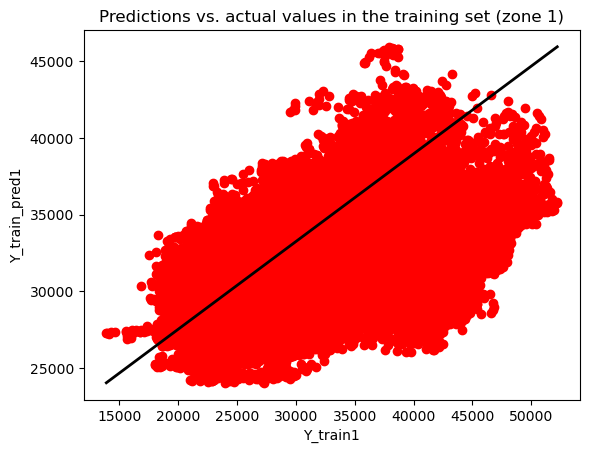

In [39]:
#Testing the first model on the first training set

h_theta1 = np.transpose(theta1)@x_train_Aug1
y_train_pred1 = np.transpose(h_theta1)

plt.scatter(y_train1, y_train_pred1, color='r')
plt.plot([y_train1.min(), y_train1.max()], [y_train_pred1.min(), y_train_pred1.max()], color = 'black', lw=2)
plt.xlabel("Y_train1")
plt.ylabel("Y_train_pred1")
plt.title("Predictions vs. actual values in the training set (zone 1)")

Text(0.5, 1.0, 'Predictions vs. actual values in the training set (zone 2)')

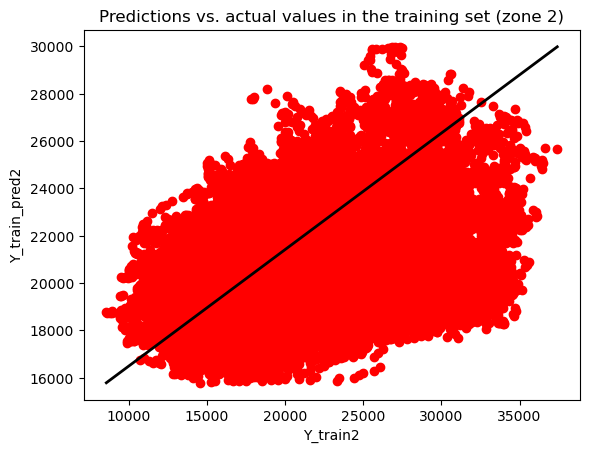

In [40]:
#Testing the second model on the second training set

h_theta2 = np.transpose(theta2)@x_train_Aug2
y_train_pred2 = np.transpose(h_theta2)

plt.scatter(y_train2, y_train_pred2, color='r')
plt.plot([y_train2.min(), y_train2.max()], [y_train_pred2.min(), y_train_pred2.max()], color = 'black', lw=2)
plt.xlabel("Y_train2")
plt.ylabel("Y_train_pred2")
plt.title("Predictions vs. actual values in the training set (zone 2)")

Text(0.5, 1.0, 'Predictions vs. actual values in the training set (zone 3)')

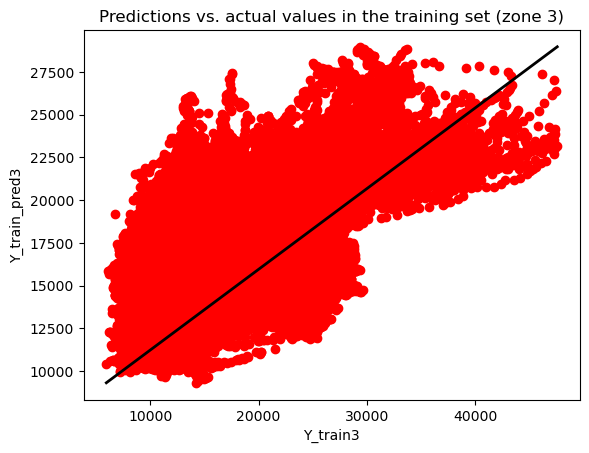

In [41]:
#Testing the third model on the third training set

h_theta3 = np.transpose(theta3)@x_train_Aug3
y_train_pred3 = np.transpose(h_theta3)

plt.scatter(y_train3, y_train_pred3, color='r')
plt.plot([y_train3.min(), y_train3.max()], [y_train_pred3.min(), y_train_pred3.max()], color = 'black', lw=2)
plt.xlabel("Y_train3")
plt.ylabel("Y_train_pred3")
plt.title("Predictions vs. actual values in the training set (zone 3)")

Text(0.5, 1.0, 'Predictions vs. actual values in the test set (zone 1)')

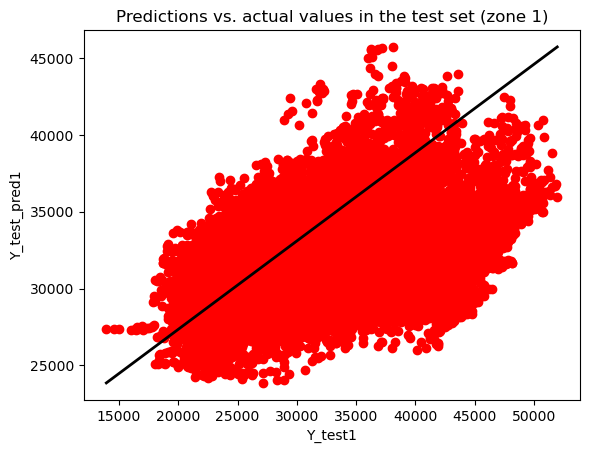

In [42]:
#Testing the first model on the first test set

h_theta1 = np.transpose(theta1)@x_test_Aug1
y_test_pred1 = np.transpose(h_theta1)

plt.scatter(y_test1, y_test_pred1, color='r')
plt.plot([y_test1.min(), y_test1.max()], [y_test_pred1.min(), y_test_pred1.max()], color = 'black', lw=2)
plt.xlabel("Y_test1")
plt.ylabel("Y_test_pred1")
plt.title("Predictions vs. actual values in the test set (zone 1)")

Text(0.5, 1.0, 'Predictions vs. actual values in the test set (zone 2)')

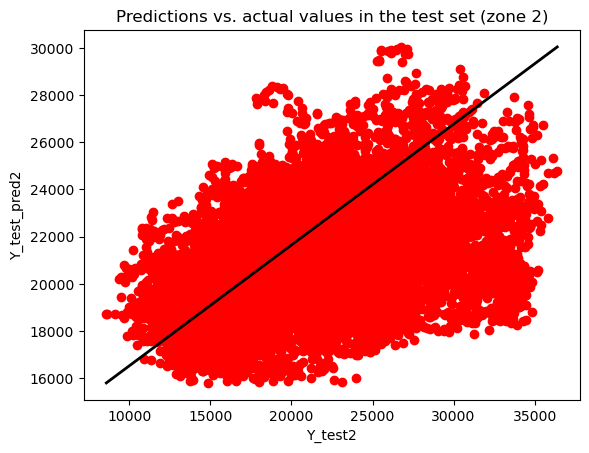

In [43]:
#Testing the second model on the second test set

h_theta2 = np.transpose(theta2)@x_test_Aug2
y_test_pred2 = np.transpose(h_theta2)

plt.scatter(y_test2, y_test_pred2, color='r')
plt.plot([y_test2.min(), y_test2.max()], [y_test_pred2.min(), y_test_pred2.max()], color = 'black', lw=2)
plt.xlabel("Y_test2")
plt.ylabel("Y_test_pred2")
plt.title("Predictions vs. actual values in the test set (zone 2)")

Text(0.5, 1.0, 'Predictions vs. actual values in the test set (zone 3)')

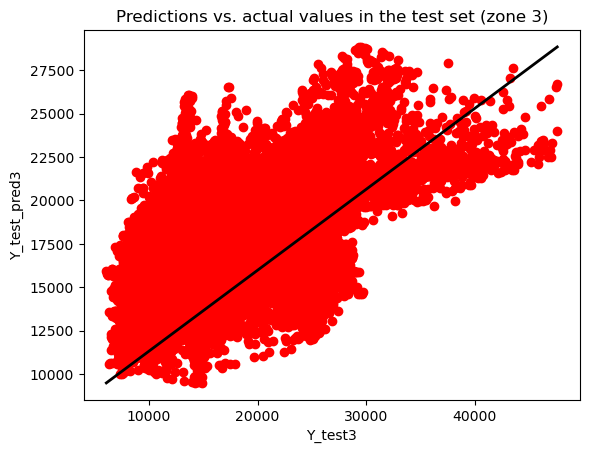

In [44]:
#Testing the third model on the third test set

h_theta3 = np.transpose(theta3)@x_test_Aug3
y_test_pred3 = np.transpose(h_theta3)

plt.scatter(y_test3, y_test_pred3, color='r')
plt.plot([y_test3.min(), y_test3.max()], [y_test_pred3.min(), y_test_pred3.max()], color = 'black', lw=2)
plt.xlabel("Y_test3")
plt.ylabel("Y_test_pred3")
plt.title("Predictions vs. actual values in the test set (zone 3)")

Text(0.5, 1.0, 'Cost function vs. number of iterations')

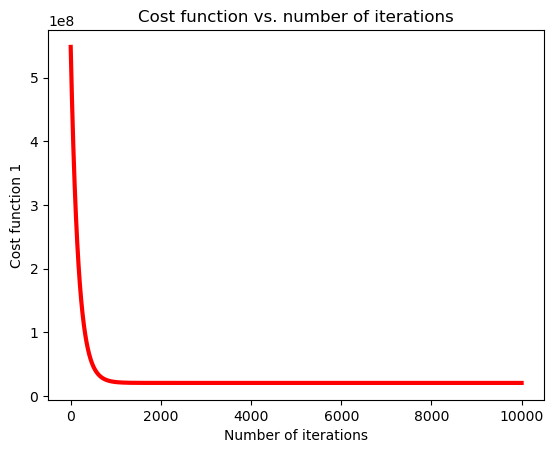

In [45]:
#Plotting cost function vs. number of iterations for set 1

plt.plot(no_of_iter[:9999],costfunc1[:9999],color='r',linewidth = '3')
plt.xlabel("Number of iterations")
plt.ylabel("Cost function 1")
plt.title("Cost function vs. number of iterations")

Text(0.5, 1.0, 'Cost function vs. number of iterations')

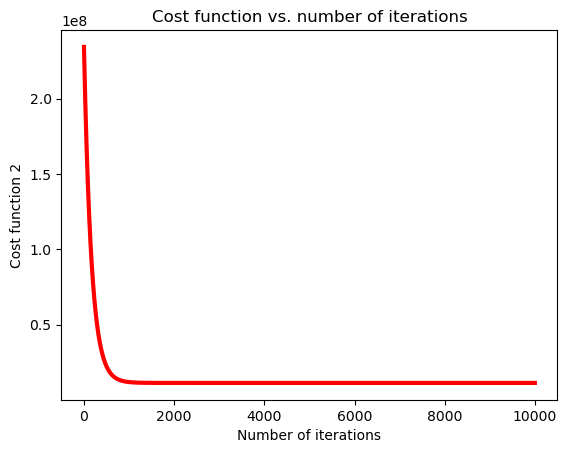

In [46]:
#Plotting cost function vs. number of iterations for set 2

plt.plot(no_of_iter[:9999],costfunc2[:9999],color='r',linewidth = '3')
plt.xlabel("Number of iterations")
plt.ylabel("Cost function 2")
plt.title("Cost function vs. number of iterations")

Text(0.5, 1.0, 'Cost function vs. number of iterations')

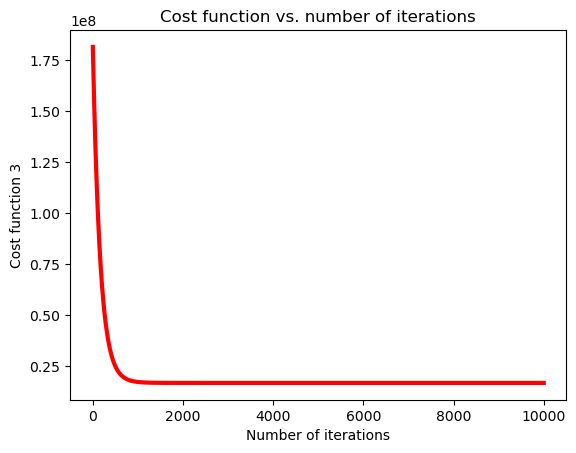

In [47]:
#Plotting cost function vs. number of iterations for set 3

plt.plot(no_of_iter[:9999],costfunc3[:9999],color='r',linewidth = '3')
plt.xlabel("Number of iterations")
plt.ylabel("Cost function 3")
plt.title("Cost function vs. number of iterations")

In [50]:
#Computing the MSE and the RMSE values for the predictions made on the training sets

MSE_train1 = (1/m_train)*(np.sum((y_train1-y_train_pred1)**2))
RMSE_train1 = np.sqrt(MSE_train1)

MSE_train2 = (1/m_train)*(np.sum((y_train2-y_train_pred2)**2))
RMSE_train2 = np.sqrt(MSE_train2)

MSE_train3 = (1/m_train)*(np.sum((y_train3-y_train_pred3)**2))
RMSE_train3 = np.sqrt(MSE_train3)

print('df1:')
print(MSE_train1)
print(RMSE_train1)
print()

print('df2:')
print(MSE_train2)
print(RMSE_train2)
print()

print('df3:')
print(MSE_train3)
print(RMSE_train3)

df1:
40617241.1077152
6373.165705339474

df2:
22400481.55587892
4732.91469983127

df3:
33211308.93731478
5762.925380161952


In [51]:
#Computing the MSE and the RMSE values for the predictions made on the test set

MSE_test1 = (1/m_test)*(np.sum((y_test1-y_test_pred1)**2))
RMSE_test1 = np.sqrt(MSE_test1)

MSE_test2 = (1/m_test)*(np.sum((y_test2-y_test_pred2)**2))
RMSE_test2 = np.sqrt(MSE_test2)

MSE_test3 = (1/m_test)*(np.sum((y_test3-y_test_pred3)**2))
RMSE_test3 = np.sqrt(MSE_test3)

print('df1:')
print(MSE_test1)
print(RMSE_test1)
print()

print('df2:')
print(MSE_test2)
print(RMSE_test2)
print()

print('df3:')
print(MSE_test3)
print(RMSE_test3)

df1:
40125152.66505046
6334.441780066375

df2:
22979147.99948599
4793.657059019344

df3:
33241997.504261855
5765.58735119518


## Model Implementation Using the Scikit-Learn Library

In [28]:
x = power.iloc[:, 1:4]
y1 = power.iloc[:, 4]
y2 = power.iloc[:, 5]
y3 = power.iloc[:, 6]
print(x.head())
print(y1.head())
print(y2.head())
print(y3.head())

   Temperature  Humidity  Wind Speed
0        6.559      73.8       0.083
1        6.414      74.5       0.083
2        6.313      74.5       0.080
3        6.121      75.0       0.083
4        5.921      75.7       0.081
0    34055.69620
1    29814.68354
2    29128.10127
3    28228.86076
4    27335.69620
Name: Zone 1 Power Consumption, dtype: float64
0    16128.87538
1    19375.07599
2    19006.68693
3    18361.09422
4    17872.34043
Name: Zone 2 Power Consumption, dtype: float64
0    20240.96386
1    20131.08434
2    19668.43373
3    18899.27711
4    18442.40964
Name: Zone 3 Power Consumption, dtype: float64


In [29]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x = sc_x.fit_transform(x.astype(float))
x

array([[-2.10664461,  0.35627749, -0.7989004 ],
       [-2.13157832,  0.40129059, -0.7989004 ],
       [-2.14894594,  0.40129059, -0.80017763],
       ...,
       [-2.0480074 ,  0.29197306, -0.79762318],
       [-2.07242524,  0.30483395, -0.80017763],
       [-2.10303352,  0.37556882, -0.79975189]], shape=(52416, 3))

In [30]:
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y1, test_size=0.333333)
x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y2, test_size=0.333333)
x_train3, x_test3, y_train3, y_test3 = train_test_split(x, y3, test_size=0.333333)

In [31]:
from sklearn.linear_model import LinearRegression
lm1 = LinearRegression()
lm1.fit(x_train1,y_train1)

lm2 = LinearRegression()
lm2.fit(x_train2, y_train2)

lm3 = LinearRegression()
lm3.fit(x_train3, y_train3)

print("Zone 1 Coeff:", lm1.coef_)
print("Zone 1 Intercept:", lm1.intercept_)

print("Zone 2 Coeff:", lm2.coef_)
print("Zone 2 Intercept:", lm2.intercept_)

print("Zone 3 Coeff:", lm3.coef_)
print("Zone 3 Intercept:", lm3.intercept_)

Zone 1 Coeff: [2935.99045494 -765.37212176 -291.75870639]
Zone 1 Intercept: 32346.63646216699
Zone 2 Coeff: [1702.33086887 -748.62481588 -144.00622545]
Zone 2 Intercept: 21054.101382569046
Zone 3 Coeff: [3043.81366396  -93.31845722  399.84244973]
Zone 3 Intercept: 17843.860814854732


# Zone 1

Text(0.5, 1.0, 'Zone 1 Predictions vs. actual values in the training set')

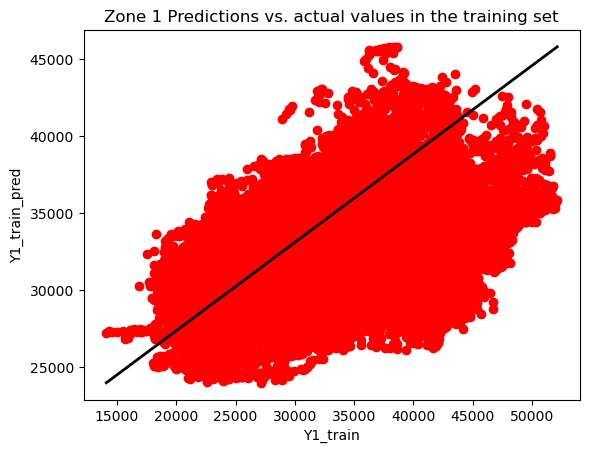

In [32]:
y1_train_pred = lm1.predict(x_train1)
plt.scatter(y_train1,y1_train_pred,color='r')
plt.plot([y_train1.min(), y_train1.max()], [y1_train_pred.min(), y1_train_pred.max()], color = 'black', lw=2)
plt.xlabel("Y1_train")
plt.ylabel("Y1_train_pred")
plt.title("Zone 1 Predictions vs. actual values in the training set")

Text(0.5, 1.0, 'Zone 1 Predictions vs. actual values in the test set')

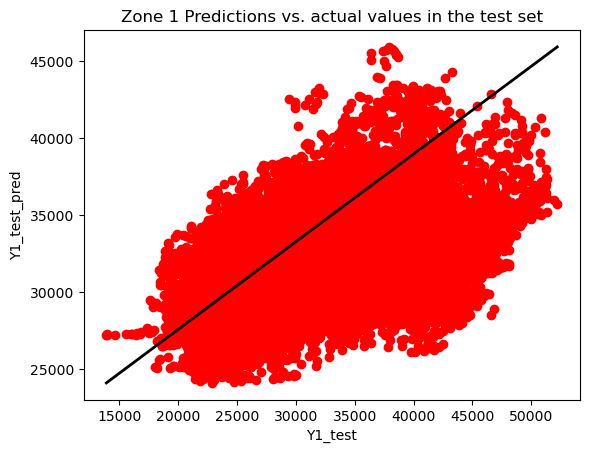

In [33]:
y1_test_pred = lm1.predict(x_test1)
plt.scatter(y_test1,y1_test_pred,color='r')
plt.plot([y_test1.min(), y_test1.max()], [y1_test_pred.min(), y1_test_pred.max()], color = 'black', lw=2)
plt.xlabel("Y1_test")
plt.ylabel("Y1_test_pred")
plt.title("Zone 1 Predictions vs. actual values in the test set")

In [34]:
from sklearn import metrics

MSE_train1 = metrics.mean_squared_error(y_train1, y1_train_pred)
RMSE_train1 = np.sqrt(MSE_train1)   
                                       
print(MSE_train1)
print(RMSE_train1)

40457099.998776786
6360.58959521653


In [35]:
MSE_test1 = metrics.mean_squared_error(y_test1, y1_test_pred)
RMSE_test1 = np.sqrt(MSE_test1)  

print(MSE_test1)
print(RMSE_test1)

40443939.9875357
6359.555014899683


# Zone 2

Text(0.5, 1.0, 'Zone 2 Predictions vs. actual values in the training set')

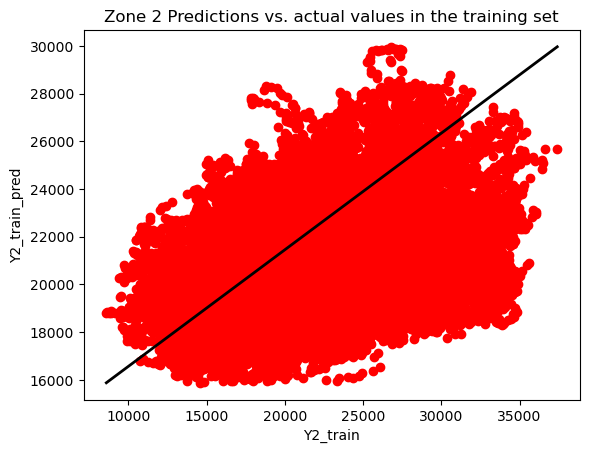

In [36]:
y2_train_pred = lm2.predict(x_train2)
plt.scatter(y_train2,y2_train_pred,color='r')
plt.plot([y_train2.min(), y_train2.max()], [y2_train_pred.min(), y2_train_pred.max()], color = 'black', lw=2)
plt.xlabel("Y2_train")
plt.ylabel("Y2_train_pred")
plt.title("Zone 2 Predictions vs. actual values in the training set")

Text(0.5, 1.0, 'Zone 2 Predictions vs. actual values in the test set')

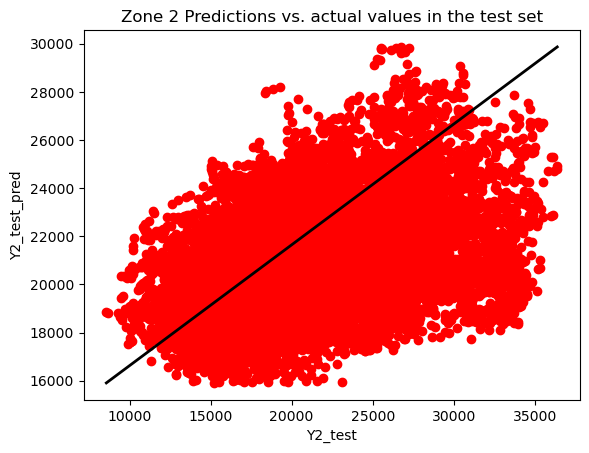

In [37]:
y2_test_pred = lm2.predict(x_test2)
plt.scatter(y_test2,y2_test_pred,color='r')
plt.plot([y_test2.min(), y_test2.max()], [y2_test_pred.min(), y2_test_pred.max()], color = 'black', lw=2)
plt.xlabel("Y2_test")
plt.ylabel("Y2_test_pred")
plt.title("Zone 2 Predictions vs. actual values in the test set")

In [38]:
from sklearn import metrics

MSE_train2 = metrics.mean_squared_error(y_train2, y2_train_pred)
RMSE_train2 = np.sqrt(MSE_train2)   
                                       
print(MSE_train2)
print(RMSE_train2)

22684971.88990059
4762.874330685263


In [39]:
MSE_test2 = metrics.mean_squared_error(y_test2, y2_test_pred)
RMSE_test2 = np.sqrt(MSE_test2)  

print(MSE_test2)
print(RMSE_test2)

22410918.077165414
4734.017118385337


# Zone 3

Text(0.5, 1.0, 'Zone 3 Predictions vs. actual values in the training set')

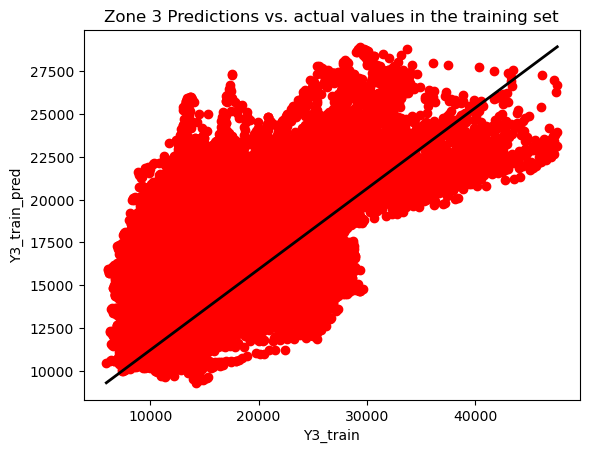

In [40]:
y3_train_pred = lm3.predict(x_train3)
plt.scatter(y_train3,y3_train_pred,color='r')
plt.plot([y_train3.min(), y_train3.max()], [y3_train_pred.min(), y3_train_pred.max()], color = 'black', lw=2)
plt.xlabel("Y3_train")
plt.ylabel("Y3_train_pred")
plt.title("Zone 3 Predictions vs. actual values in the training set")

Text(0.5, 1.0, 'Zone 3 Predictions vs. actual values in the test set')

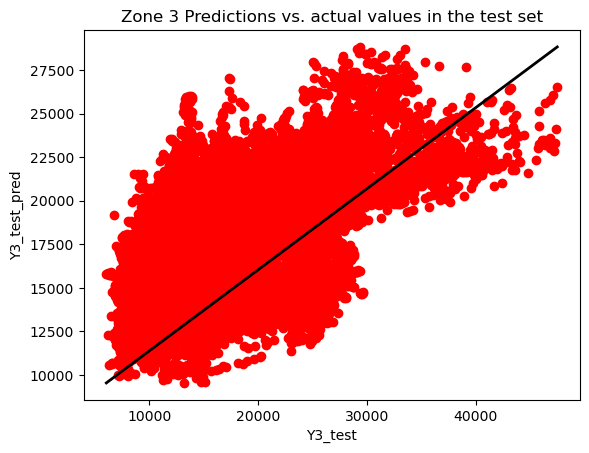

In [41]:
y3_test_pred = lm3.predict(x_test3)
plt.scatter(y_test3,y3_test_pred,color='r')
plt.plot([y_test3.min(), y_test3.max()], [y3_test_pred.min(), y3_test_pred.max()], color = 'black', lw=2)
plt.xlabel("Y3_test")
plt.ylabel("Y3_test_pred")
plt.title("Zone 3 Predictions vs. actual values in the test set")

In [42]:
from sklearn import metrics

MSE_train3 = metrics.mean_squared_error(y_train3, y3_train_pred)
RMSE_train3 = np.sqrt(MSE_train3)   
                                       
print(MSE_train3)
print(RMSE_train3)

33371988.79625915
5776.849383207004


In [43]:
MSE_test3 = metrics.mean_squared_error(y_test3, y3_test_pred)
RMSE_test3 = np.sqrt(MSE_test3)  

print(MSE_test3)
print(RMSE_test3)

32918382.261408787
5737.454336324498
